# Resumo Capítulo 2 - Projeto de ML de Ponta a Ponta

## Fluxo do projeto:

Antes de darmos início ao nosso projeto, primeiro vamos discorrer sobre como será o fluxo do nosso projeto. Ele será dividido em 8 passos:

    - Analisar o panorama geral do problema
    - Obter os dados
    - Visualizar os dados para obter insights
    - Preparar os dados (Limpeza e engenharia de features)
    - Selecionar e treinar o modelo
    - Aperfeiçoar o modelo
    - Apresentar o modelo
    - Subir em produção, monitorar e fazer manutenções

## Objetivo do projeto:

Nosso objetivo será de treinar um modelo que consiga prever o preço médio dos imóveis de uma região da Califórnia a partir dos dados de um censo de 1990, o conjunto de dados possui características como população, renda média, dentre outras, e a partir dessas devemos prever o preço médio de um imóvel.

Antes de começarmos a selecionar o modelo e a medida de desempenho precisamos entender o que o nosso cliente quer, não apenas entregar um modelo, para isso precisamos saber como o nosso cliente vai usar o modelo e como ele será beneficiado(acho um pouco invasivo essa pergunta, porém não custa citar :)), além disso precisamos saber a solução atual(se houver) para que possamos utilizá-la como um guia, além de analisarmos os pontos onde são necessárias melhorias.

Nosso cliente disse que as informações obtidas a partir do modelo que iremos criar irá alimentar um data store, o qual irá fornecer dados para um modelo de análise financeira, atualmente os preços médios dos imóveis são definidos manualmente por especialistas, seguindo várias regras complexas, porém esses preços médios estão sendo definidos um pouco abaixo do que deveriam, causando a diminuição no faturamento da empresa, visto que as análises financeiras acabam prejudicadas.

## Definindo o que iremos usar:

Para começar, pense um pouco, que tipo de aprendizado será utilizado, supervisionado, não supervisionado ou por reforço? Que tipo de tarefa estamos realizando, regressão ou classificação? Iremos utilizar técnicas de aprendizado em batch ou online? Antes de ver o próximo parágrafo responda essas perguntas, com a base que foi obtida a partir do capítulo anterior você já é capaz de responder essas perguntas, se desafie!

O nosso problema utilizará um algoritmo de aprendizado supervisionado, visto que os dados que iremos utilizar estão rotulados com os preços médios por região, como queremos prever um valor numérico vamos realizar uma tarefa de regressão, e indo um pouco além, iremos utilizar um modelo de regressão múltipla, pois estamos utilizando mais de uma característica para prever nosso valor, e de regressão univariada, pois queremos prever apenas um valor, por fim, como não há a necessidade de atualização em tempo real do modelo e temos recursos computacionais o suficiente para fazer o treinamento com todos os dados de uma vez, vamos utilizar técnicas de aprendizado em batch.

Nota => Caso nosso conjunto de dados fosse muito grande, poderíamos distribuir o treino em vários servidores e cada um realizar técnicas de aprendizado em batch, sendo possível de fazer isso a partir da técnica de **MapReduce**. Ou poderíamos utilizar uma técnica de aprendizado online.

## Escolhendo a medida de desempenho:

Para começar vamos escolher uma medida de desempenho, para problemas de regressão uma das medidas mais usadas é a **Raiz do Erro Quadrático Médio** ou **RMSE**, definida matemáticamente por:

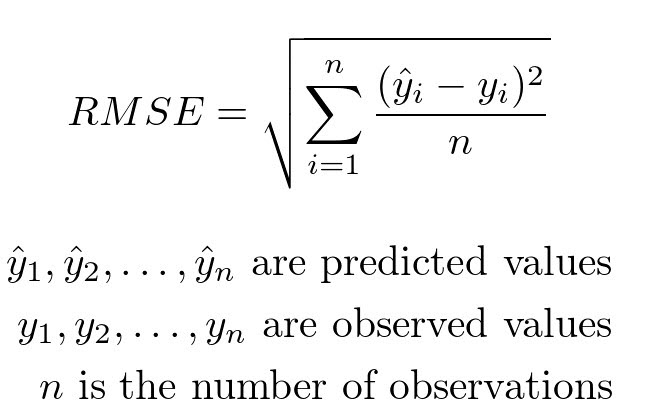

chamamos o y^ de **hipótese h(x)**, que nada mais representa o valor da função de previsão utilizada no modelo.

Dizemos que essa métrica utiliza a **norma euclidiana**, utilizada para calcular a distância entre dois vetores, então podemos definir a fórmula da seguinte maneira:

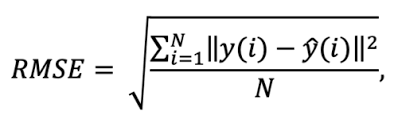

A RMSE é uma métrica utilizada quando outliers são raros no conjunto de dados, pois por elevar o erro ao quadrado ela se torna mais sensível a erros grandes, ou seja, outliers, desse modo, se o nosso dataset possuísse muitos outliers, não conseguiríamos saber se o valor alto do erro seria a soma de muitos erros pequenos ou a soma de poucos erros grandes.Para contornar essa situação, poderíamos utilizar outra métrica muito usada em tarefas de regressão, o **Erro Médio Absoluto** ou **MAE**.

A métrica MAE utiliza a **norma de manhattan** para calcular a distância entre os vetores de valores de previsão e os vetores de valores reais, enquanto a norma euclidiana utiliza o quadrado da distância, essa norma utiliza o módulo da distância:

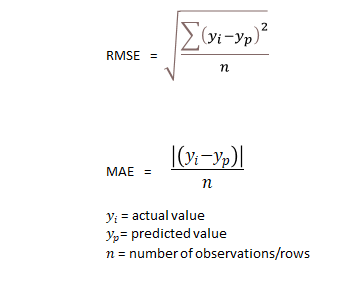

Por utilizar o módulo essa métrica é muito utilizada quando o conjunto de dados possui muitos ouliers, já que ela é menos sensível a eles. 
